In [22]:
import yfinance as yf
import pandas as pd
import numpy as np
import talib
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Dense, Dropout, BatchNormalization
from sklearn.metrics import classification_report


In [23]:
# ---------- CONFIG (เหมือนเดิม) ----------
TICKERS = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'NVDA', 'JPM', 'V', 'UNH',
    'MA', 'XOM', 'PFE', 'WMT', 'DIS', 'BAC', 'KO', 'INTC', 'CSCO', 'ORCL',
    'BTC-USD', 'ETH-USD', 'BNB-USD', 'SOL-USD', 'XRP-USD', 'ADA-USD',
    'DOGE-USD', 'AVAX-USD', 'TRX-USD', 'LINK-USD','TON-USD','ARB-USD',
    'OP-USD','APT-USD','STX-USD'
]
START = "2014-01-01"
END = "2024-12-31"
WINDOW_SIZE = 5
SELECTED_PATTERNS = [
    'CDLDOJI', 'CDLSPINNINGTOP', 'CDLMARUBOZU', 'CDLENGULFING',
    'CDLGRAVESTONEDOJI', 'CDLHAMMER', 'CDLDRAGONFLYDOJI'
]

# ---------- 1. โหลดและคำนวณ Label (เหมือนเดิม) ----------
df = yf.download(TICKERS, start=START, end=END, group_by='ticker', auto_adjust=False, progress=False)
all_data_with_labels = []

for ticker in TICKERS:
    try:
        df_ticker = df[ticker][['Open', 'High', 'Low', 'Close']].dropna().copy()
        open_ = df_ticker['Open'].values.astype(float)
        high_ = df_ticker['High'].values.astype(float)
        low_ = df_ticker['Low'].values.astype(float)
        close_ = df_ticker['Close'].values.astype(float)

        labels = pd.DataFrame(index=df_ticker.index)
        for pattern in SELECTED_PATTERNS:
            func = getattr(talib, pattern)
            out = func(open_, high_, low_, close_)
            labels[pattern + "_bull"] = (out == 100).astype(int)
            labels[pattern + "_bear"] = (out == -100).astype(int)

        combined = pd.concat([df_ticker, labels], axis=1)
        all_data_with_labels.append(combined)
    except Exception as e:
        print(f"❌ Error processing {ticker}: {e}")

final_dataset = pd.concat(all_data_with_labels, ignore_index=True)

# กรอง Label ที่ไม่มีข้อมูลเลย
label_cols = [col for col in final_dataset.columns if '_bull' in col or '_bear' in col]
support = final_dataset[label_cols].sum()
pattern_cols = support[support > 0].index.tolist()
feature_cols = ['Open', 'High', 'Low', 'Close']
final_dataset = final_dataset[feature_cols + pattern_cols]

# กรองแถวที่ไม่มี Pattern เลย เพื่อลดขนาดข้อมูลเริ่มต้น
final_dataset = final_dataset[final_dataset[pattern_cols].sum(axis=1) > 0].reset_index(drop=True)
print(f"✅ Dataset shape after initial filtering: {final_dataset.shape}")


✅ Dataset shape after initial filtering: (33308, 14)


In [24]:
# ---------- 2. สร้าง Window Dataset และ Normalize ----------
def create_windowed_dataset_and_normalize(data, feature_cols, label_cols, window_size):
    X_list, y_list = [], []
    features_np = data[feature_cols].values
    labels_np = data[label_cols].values

    for i in range(len(data) - window_size + 1):
        window_indices = range(i, i + window_size)
        window_features = features_np[window_indices]
        
        # Normalize ภายใน window
        max_H = np.max(window_features[:, 1])
        min_L = np.min(window_features[:, 2])
        range_val = max_H - min_L
        normalized_window = (window_features - min_L) / range_val if range_val > 0 else np.zeros_like(window_features)
        
        # Label ของ window คือการรวม label ทั้ง 5 วัน
        window_labels = labels_np[window_indices]
        combined_label = (window_labels.sum(axis=0) > 0).astype(int)
        
        X_list.append(normalized_window)
        y_list.append(combined_label)
        
    return np.array(X_list), np.array(y_list)

X_window, y_window = create_windowed_dataset_and_normalize(final_dataset, feature_cols, pattern_cols, WINDOW_SIZE)
print(f"✅ Windowed data shape: X={X_window.shape}, y={y_window.shape}")


✅ Windowed data shape: X=(33304, 5, 4), y=(33304, 10)


In [25]:
# ---------- 3. Oversampling ข้อมูล ----------
def oversample_multilabel(X, y, target_count_per_class=50000):
    X_resampled, y_resampled = list(X), list(y)
    
    for i in range(y.shape[1]): # วนลูปแต่ละ pattern
        # หา index ของ sample ที่มี pattern นี้
        positive_indices = np.where(y[:, i] == 1)[0]
        current_count = len(positive_indices)
        
        if 0 < current_count < target_count_per_class:
            n_to_add = target_count_per_class - current_count
            
            # สุ่มตัวอย่างจาก sample ที่มี pattern นี้มาเพิ่ม
            resampled_indices = resample(positive_indices, replace=True, n_samples=n_to_add, random_state=42)
            
            X_resampled.extend(X[resampled_indices])
            y_resampled.extend(y[resampled_indices])
            
    return np.array(X_resampled), np.array(y_resampled)

X_os, y_os = oversample_multilabel(X_window, y_window)
print(f"✅ Oversampled data shape: X={X_os.shape}, y={y_os.shape}")

# ---------- 4. แบ่งข้อมูลและสร้างโมเดล (เหมือนเดิม) ----------
X_train, X_val, y_train, y_val = train_test_split(
    X_os, y_os, test_size=0.2, random_state=42, stratify=None
)
print(f"📦 Training shape: {X_train.shape}, {y_train.shape}")
print(f"🧪 Validation shape: {X_val.shape}, {y_val.shape}")


✅ Oversampled data shape: X=(377491, 5, 4), y=(377491, 10)
📦 Training shape: (301992, 5, 4), (301992, 10)
🧪 Validation shape: (75499, 5, 4), (75499, 10)


In [26]:
model = Sequential([
    Conv1D(64, kernel_size=1, padding='same', activation='relu', input_shape=(WINDOW_SIZE, 4)),
    Conv1D(64, kernel_size=2, padding='same', activation='relu'),
    Conv1D(64, kernel_size=3, padding='same', activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dense(y_train.shape[1], activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

c:\Users\User\Desktop\Project\env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_9 (Conv1D)               │ (None, 5, 64)          │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 5, 64)          │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 5, 64)          │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 5, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,994 (101.54 KB)

 Trainable params: 25,866 (101.04 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/15
9438/9438 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - accuracy: 0.5820 - loss: 0.4103 - val_accuracy: 0.1650 - val_loss: 0.2643
Epoch 2/15
9438/9438 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.2810 - loss: 0.2600 - val_accuracy: 0.2354 - val_loss: 0.2398
Epoch 3/15
9438/9438 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.3052 - loss: 0.2408 - val_accuracy: 0.2101 - val_loss: 0.2401
Epoch 4/15
9438/9438 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.3096 - loss: 0.2312 - val_accuracy: 0.1995 - val_loss: 0.2224
Epoch 5/15
9438/9438 ━━━━━━━━━━━━━━━━━━━━ 36s 4ms/step - accuracy: 0.3301 - loss: 0.2254 - val_accuracy: 0.4435 - val_loss: 0.2097
Epoch 6/15
9438/9438 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.3369 - loss: 0.2210 - val_accuracy: 0.3158 - val_loss: 0.2073
Epoch 7/15
9438/9438 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.3316 - loss: 0.2163 - val_accuracy: 0.2510 - val_loss: 0.2094
Epoch 8/15
9438/9438 ━━━━━━━━━━━━━━━━━━━━ 36s 4ms/step - accuracy: 0.3360 - loss: 0

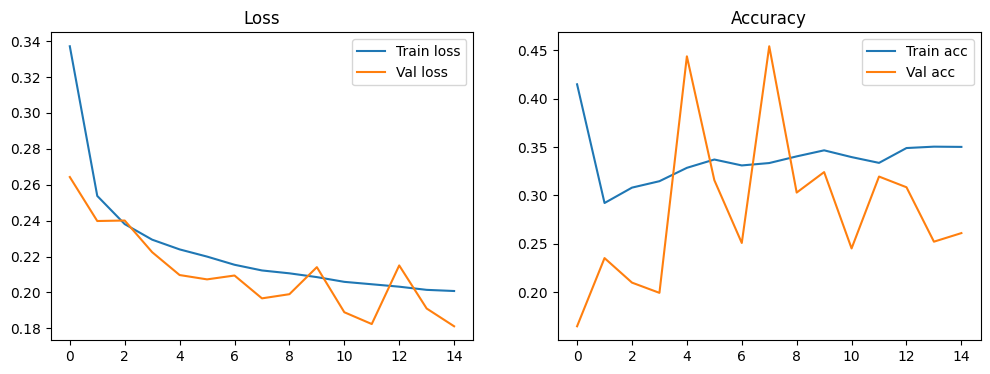

In [27]:
# ---------- 5. ฝึกโมเดลและประเมินผล (เหมือนเดิม) ----------
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    verbose=1,
)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train acc')
plt.plot(history.history['val_accuracy'], label='Val acc')
plt.title('Accuracy')
plt.legend()
plt.show()

In [28]:
y_pred = model.predict(X_val)
y_pred_bin = (y_pred > 0.5).astype(int)

print("📊 Classification Report:")
print(classification_report(y_val, y_pred_bin, target_names=pattern_cols))

2360/2360 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
📊 Classification Report:
                        precision    recall  f1-score   support

          CDLDOJI_bull       0.98      0.97      0.97     69677
   CDLSPINNINGTOP_bull       0.98      0.98      0.98     59468
   CDLSPINNINGTOP_bear       0.97      0.99      0.98     57992
      CDLMARUBOZU_bull       0.92      0.97      0.95     26261
      CDLMARUBOZU_bear       0.91      0.98      0.94     24738
     CDLENGULFING_bull       0.94      0.81      0.87     34540
     CDLENGULFING_bear       0.89      0.88      0.88     37090
CDLGRAVESTONEDOJI_bull       0.93      0.75      0.83     20890
        CDLHAMMER_bull       0.84      0.82      0.83     29082
 CDLDRAGONFLYDOJI_bull       0.86      0.81      0.83     23892

             micro avg       0.94      0.92      0.93    383630
             macro avg       0.92      0.90      0.91    383630
          weighted avg       0.94      0.92      0.93    383630
           samples avg       0.94 

เกิดข้อผิดพลาดในการบันทึกโมเดล Keras: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=my_keras_classification_model.
